Current Python Version: 3.12.12
Notice: PyCaret is incompatible with Python 3.12. Using direct Scikit-Learn implementation.
Generating Moon Data...
Running DBSCAN (eps=0.3, min_samples=5)...

--- Results ---
Estimated number of clusters: 2
Estimated number of noise points: 0
Silhouette Score: 0.3893

Plotting Clusters...


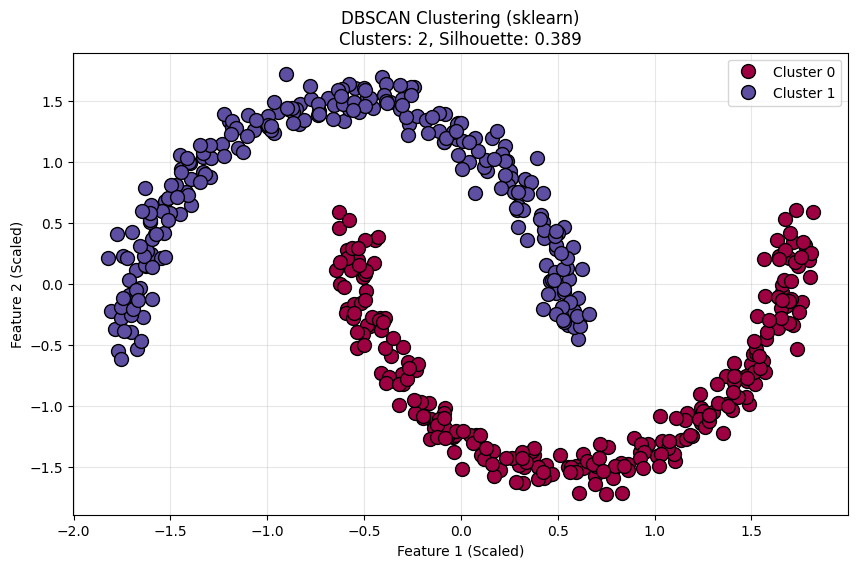

In [2]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# --- 1. Environment Check ---
print(f"Current Python Version: {sys.version.split()[0]}")
if sys.version_info >= (3, 12):
    print("Notice: PyCaret is incompatible with Python 3.12. Using direct Scikit-Learn implementation.")

# --- 2. Data Generation ---
print("Generating Moon Data...")
X, _ = make_moons(n_samples=500, noise=0.05, random_state=42)

# DBSCAN works best with scaled data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. Model Training (DBSCAN) ---
# eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
# min_samples: The number of samples in a neighborhood for a point to be considered as a core point.
print("Running DBSCAN (eps=0.3, min_samples=5)...")
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# --- 4. Evaluation ---
# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"\n--- Results ---")
print(f"Estimated number of clusters: {n_clusters_}")
print(f"Estimated number of noise points: {n_noise_}")

if n_clusters_ > 1:
    score = silhouette_score(X_scaled, labels)
    print(f"Silhouette Score: {score:.4f}")
else:
    print("Silhouette Score: N/A (Not enough clusters)")

# --- 5. Visualization ---
print("\nPlotting Clusters...")
plt.figure(figsize=(10, 6))

# Mask for noise (label -1) and clusters
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]
        label_name = "Noise"
    else:
        label_name = f"Cluster {k}"

    class_member_mask = (labels == k)

    xy = X_scaled[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=10, label=label_name)

plt.title(f'DBSCAN Clustering (sklearn)\nClusters: {n_clusters_}, Silhouette: {score:.3f}')
plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()